# 01 EDA and First Feature Engineering Step

This notebook loads the raw supply-chain dataset, performs basic EDA, and previews the first feature-engineering outputs from `src/features.py`.

In [2]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.features import build_feature_dataframe

Matplotlib is building the font cache; this may take a moment.


In [3]:
data_path = os.path.join(project_root, 'data', 'raw', 'DataCoSupplyChainDataset.csv')
df = pd.read_csv(data_path, encoding='latin-1')
print('shape:', df.shape)
print('dtypes:\n', df.dtypes)
print('nulls:\n', df.isna().sum().sort_values(ascending=False).head(20))

shape: (180519, 53)
dtypes:
 Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                   

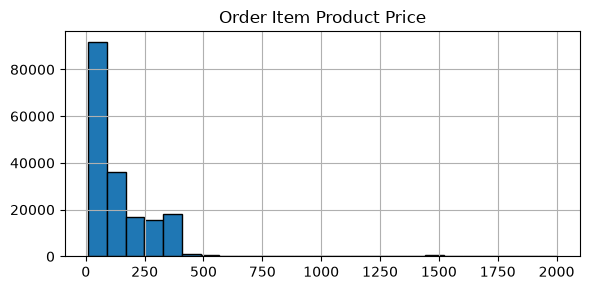

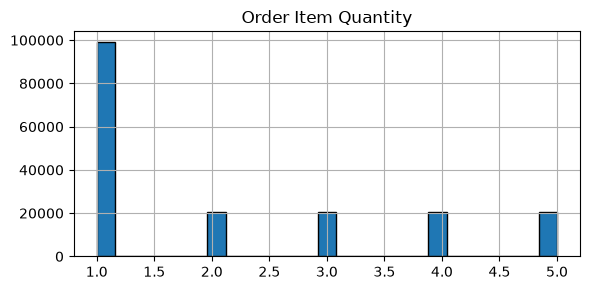

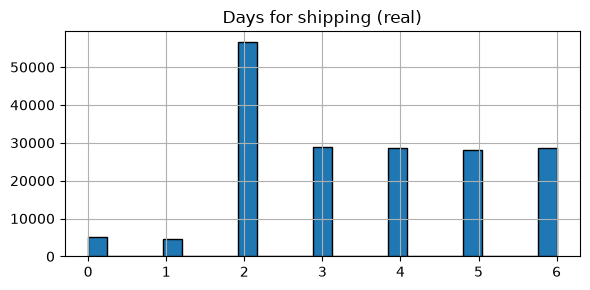

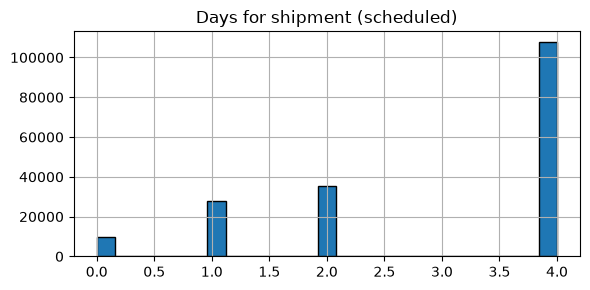

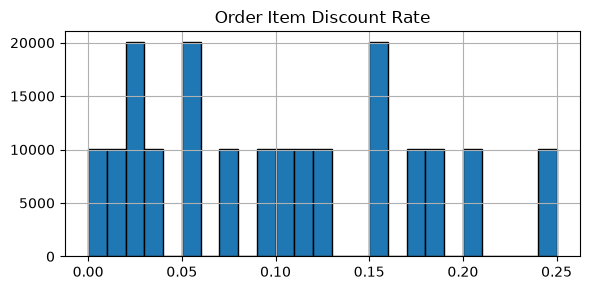

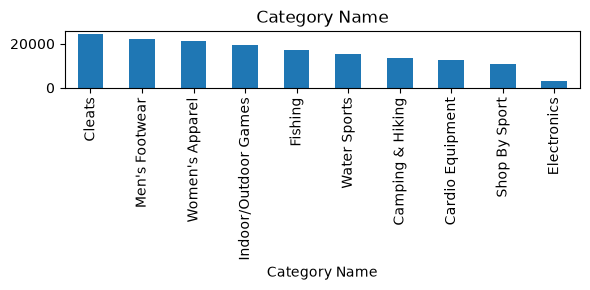

In [4]:
key_columns = [
    'Order Item Product Price',
    'Order Item Quantity',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Order Item Discount Rate',
    'Category Name',
]

for column in key_columns:
    if column in df.columns:
        plt.figure(figsize=(6, 3))
        if pd.api.types.is_numeric_dtype(df[column]):
            df[column].hist(bins=25, edgecolor='black')
        else:
            df[column].value_counts().head(10).plot(kind='bar')
        plt.title(column)
        plt.tight_layout()
        plt.show()

In [5]:
feature_df = build_feature_dataframe(df.sample(n=5000, random_state=42).copy())
feature_df[[
    'price_deviation_from_supplier_category_avg',
    'order_quantity_zscore_by_category',
    'delivery_delay_days',
    'delivery_delay_deviation',
    'discount_rate_anomaly'
]].head()

,price_deviation_from_supplier_category_avg,order_quantity_zscore_by_category,delivery_delay_days,delivery_delay_deviation,discount_rate_anomaly
80120,NaN,0.000000,1,0.258921,0.308499
19670,NaN,1.385665,1,0.322029,-1.171255
114887,NaN,1.622540,-2,-1.937837,-1.081894
120110,NaN,0.000000,1,0.376686,0.823498
56658,NaN,-0.040888,-2,-1.768300,-0.015579
